# Cross-Domain Hallucination Detection
## RAGTruth $\rightarrow$ PublicHearingBR

This notebook summarizes the frozen experiments comparing an RAGTruth-trained
detector, an off-the-shelf multilingual NLI baseline, and an in-domain
PublicHearingBR reference.

**4,235 examples · 206 hearings · 501 positives · 11.8% prevalence**


In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


EXPERIMENT_KEYS = (
    "publichearing_in_domain",
    "ragtruth_confirmatory",
    "off_the_shelf",
    "threshold_transfer",
    "thresholded_bootstrap",
    "continuous_bootstrap",
)


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "notebooks" / "configs" / "publichearing_transfer.example.yaml").is_file():
            return candidate
    raise FileNotFoundError("Repository root with the notebook configuration example was not found.")


def load_notebook_config(root: Path) -> tuple[Path, dict[str, Path]]:
    requested = os.environ.get("NOTEBOOK_CONFIG")
    config_path = Path(requested) if requested else root / "notebooks" / "configs" / "publichearing_transfer.local.yaml"
    if not config_path.is_absolute():
        config_path = root / config_path
    if not config_path.is_file():
        raise FileNotFoundError(
            "Local notebook configuration not found.\n\n"
            "Copy:\nnotebooks/configs/publichearing_transfer.example.yaml\n\nto:\n"
            "notebooks/configs/publichearing_transfer.local.yaml\n\nand configure the experiment paths."
        )
    raw = yaml.safe_load(config_path.read_text(encoding="utf-8"))
    experiments = raw.get("experiments") if isinstance(raw, dict) else None
    if not isinstance(experiments, dict):
        raise ValueError("Notebook configuration requires an experiments mapping.")
    resolved: dict[str, Path] = {}
    for key in EXPERIMENT_KEYS:
        entry = experiments.get(key)
        value = entry.get("path") if isinstance(entry, dict) else None
        relative_path = Path(value) if isinstance(value, str) else None
        if not relative_path or relative_path.is_absolute() or ".." in relative_path.parts:
            raise ValueError(f"{key} must define a repository-relative path.")
        resolved[key] = root / relative_path
    return config_path, resolved


ROOT = find_repo_root()
os.chdir(ROOT)
config_path, experiment_paths = load_notebook_config(ROOT)
try:
    config_label = config_path.relative_to(ROOT)
except ValueError:
    config_label = config_path
print(f"Configuration: {config_label}")

BASELINE_LABEL = "Off-the-shelf NLI"
RAGTRUTH_TEST_LABEL = "RAGTruth test"
LORA_LABEL = r"RAGTruth $\rightarrow$ PH"
IN_DOMAIN_LABEL = "PH in-domain"
COLORS = {
    BASELINE_LABEL: "#7b8794",
    RAGTRUTH_TEST_LABEL: "#6f42c1",
    LORA_LABEL: "#1f77b4",
    IN_DOMAIN_LABEL: "#2a9d8f",
}
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})


Configuration: notebooks/configs/publichearing_transfer.local.yaml


### Metric primer

**AUPRC** summarizes the precision–recall trade-off across thresholds. Higher is
better and it is particularly informative for imbalanced data. **AUROC** measures
how well positive examples are ranked above negative examples. Higher is better.
**Brier score** measures squared distance between score and binary label. Lower is
better. For the off-the-shelf baseline, Brier is a score-quality diagnostic rather
than proof of probability calibration.


In [2]:
def load_json(path: Path) -> dict:
    with path.open(encoding="utf-8") as handle:
        return json.load(handle)


def add_bar_labels(axis, bars, errors=None, fmt="{:.3f}", padding=0.015) -> None:
    errors = np.zeros(len(bars)) if errors is None else np.asarray(errors)
    for bar, error in zip(bars, errors):
        value = bar.get_height()
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            value + error + padding,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=8,
        )


def plot_effect_ci(axis, labels, estimates, lowers, uppers, color, title) -> None:
    positions = np.arange(len(labels))[::-1]
    errors = np.vstack([np.asarray(estimates) - np.asarray(lowers), np.asarray(uppers) - np.asarray(estimates)])
    axis.errorbar(estimates, positions, xerr=errors, fmt="o", color=color, capsize=3, lw=1.8)
    axis.axvline(0, color="#4b5563", lw=1, ls="--")
    axis.set_yticks(positions, labels)
    axis.set_title(title, loc="left", fontsize=11, weight="bold")
    axis.set_xlabel("Effect (positive = LoRA better)")
    axis.grid(axis="x", alpha=0.22)


in_domain_frame = pd.read_csv(experiment_paths["publichearing_in_domain"] / "outputs" / "overall_oof_metrics.csv")
in_domain = in_domain_frame.loc[in_domain_frame["criterion"].eq("ranking")].iloc[0]
seed_metrics = pd.read_csv(experiment_paths["ragtruth_confirmatory"] / "aggregate" / "per_seed_metrics.csv")
seed_metrics = seed_metrics.loc[seed_metrics["threshold_regime"].eq("threshold_free")]
seed_summary = seed_metrics.groupby("dataset")[["AUPRC", "AUROC", "Brier"]].agg(["mean", "std"])
baseline = load_json(experiment_paths["off_the_shelf"] / "metrics.json")
threshold_transfer = load_json(experiment_paths["threshold_transfer"] / "publichearing_metrics.json")
continuous_bootstrap = load_json(experiment_paths["continuous_bootstrap"] / "campaign_summary.json")
thresholded_bootstrap = load_json(experiment_paths["thresholded_bootstrap"] / "campaign_summary.json")

def summary(dataset: str, metric: str) -> tuple[float, float]:
    return float(seed_summary.loc[dataset, (metric, "mean")]), float(seed_summary.loc[dataset, (metric, "std")])


ragtruth = {metric: summary("ragtruth_test", metric) for metric in ("AUPRC", "AUROC", "Brier")}
zero_shot = {metric: summary("publichearing_zero_shot", metric) for metric in ("AUPRC", "AUROC", "Brier")}
in_domain_metrics = {metric: float(in_domain[metric]) for metric in ("AUPRC", "AUROC", "Brier")}
baseline_metrics = {metric: float(baseline[metric]) for metric in ("AUPRC", "AUROC", "Brier")}



### Threshold-free performance

The ranking metrics below use continuous scores, so they do not require a decision
threshold. Error bars show the standard deviation across the three LoRA seeds.


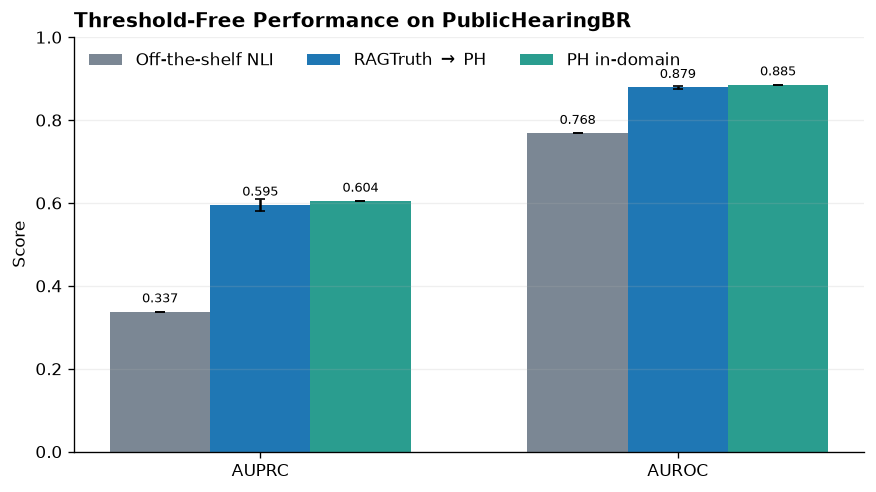

In [3]:
metrics = ["AUPRC", "AUROC"]
methods = [BASELINE_LABEL, LORA_LABEL, IN_DOMAIN_LABEL]
values = {
    BASELINE_LABEL: [baseline_metrics[metric] for metric in metrics],
    LORA_LABEL: [zero_shot[metric][0] for metric in metrics],
    IN_DOMAIN_LABEL: [in_domain_metrics[metric] for metric in metrics],
}
errors = {
    BASELINE_LABEL: [0, 0],
    LORA_LABEL: [zero_shot[metric][1] for metric in metrics],
    IN_DOMAIN_LABEL: [0, 0],
}
figure, axis = plt.subplots(figsize=(7.4, 4.2))
x = np.arange(len(metrics))
width = 0.24
for index, method in enumerate(methods):
    bars = axis.bar(x + (index - 1) * width, values[method], width, yerr=errors[method], capsize=3, label=method, color=COLORS[method])
    add_bar_labels(axis, bars)
axis.set_xticks(x, metrics)
axis.set_ylim(0, 1)
axis.set_ylabel("Score")
axis.set_title("Threshold-Free Performance on PublicHearingBR", loc="left", weight="bold")
axis.legend(frameon=False, ncols=3, loc="upper left")
axis.grid(axis="y", alpha=0.2)
figure.tight_layout()
plt.show()


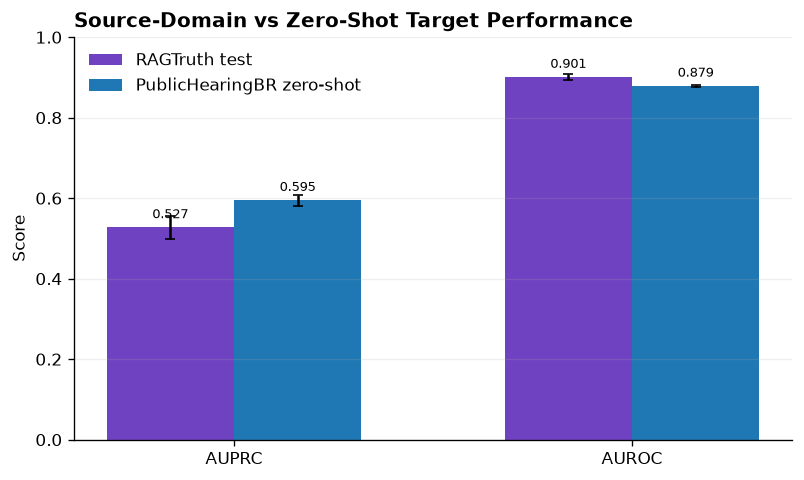

In [4]:
metrics = ["AUPRC", "AUROC"]
figure, axis = plt.subplots(figsize=(6.8, 4.1))
x = np.arange(len(metrics))
width = 0.32
source_bars = axis.bar(x - width / 2, [ragtruth[metric][0] for metric in metrics], width, yerr=[ragtruth[metric][1] for metric in metrics], capsize=3, label=RAGTRUTH_TEST_LABEL, color=COLORS[RAGTRUTH_TEST_LABEL])
target_bars = axis.bar(x + width / 2, [zero_shot[metric][0] for metric in metrics], width, yerr=[zero_shot[metric][1] for metric in metrics], capsize=3, label="PublicHearingBR zero-shot", color=COLORS[LORA_LABEL])
add_bar_labels(axis, source_bars)
add_bar_labels(axis, target_bars)
axis.set_xticks(x, metrics)
axis.set_ylim(0, 1)
axis.set_ylabel("Score")
axis.set_title("Source-Domain vs Zero-Shot Target Performance", loc="left", weight="bold")
axis.legend(frameon=False)
axis.grid(axis="y", alpha=0.2)
figure.tight_layout()
plt.show()


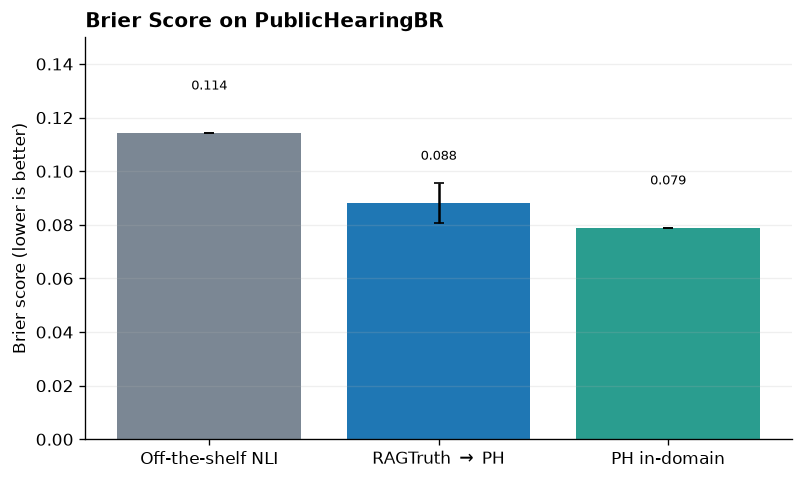

In [5]:
methods = [BASELINE_LABEL, LORA_LABEL, IN_DOMAIN_LABEL]
brier_values = [baseline_metrics["Brier"], zero_shot["Brier"][0], in_domain_metrics["Brier"]]
brier_errors = [0, zero_shot["Brier"][1], 0]
figure, axis = plt.subplots(figsize=(6.8, 4.1))
bars = axis.bar(methods, brier_values, yerr=brier_errors, capsize=3, color=[COLORS[method] for method in methods])
add_bar_labels(axis, bars)
axis.set_ylim(0, 0.15)
axis.set_ylabel("Brier score (lower is better)")
axis.set_title("Brier Score on PublicHearingBR", loc="left", weight="bold")
axis.grid(axis="y", alpha=0.2)
figure.tight_layout()
plt.show()


### Frozen operating points and uncertainty

`best_f1` and `fpr10` were selected exclusively on RAGTruth validation and frozen
before PublicHearingBR evaluation. F1 balances precision and recall. Recall is the
fraction of hallucinations detected. FPR is the fraction of negatives incorrectly
flagged. MCC and balanced accuracy are robust binary metrics under imbalance.


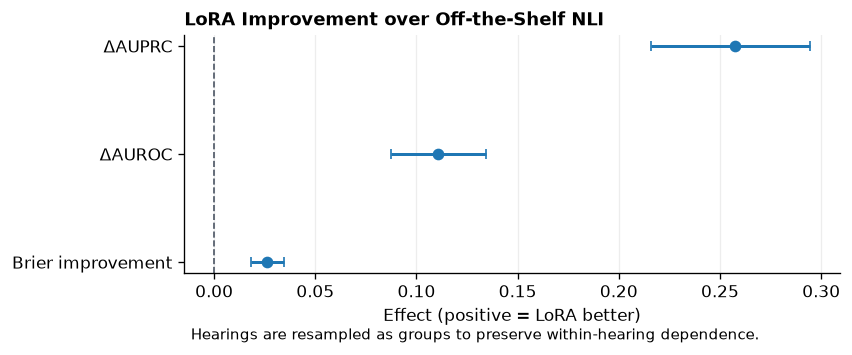

In [6]:
continuous_labels = ["ΔAUPRC", "ΔAUROC", "Brier improvement"]
continuous_keys = ["auprc", "auroc", "brier_improvement"]
estimates = [continuous_bootstrap["observed_effects"][key] for key in continuous_keys]
lowers = [continuous_bootstrap["bootstrap"][key]["ci_lower"] for key in continuous_keys]
uppers = [continuous_bootstrap["bootstrap"][key]["ci_upper"] for key in continuous_keys]
figure, axis = plt.subplots(figsize=(7.2, 3.2))
plot_effect_ci(axis, continuous_labels, estimates, lowers, uppers, COLORS[LORA_LABEL], "LoRA Improvement over Off-the-Shelf NLI")
axis.text(0.01, -0.28, "Hearings are resampled as groups to preserve within-hearing dependence.", transform=axis.transAxes, fontsize=9)
figure.tight_layout()
plt.show()


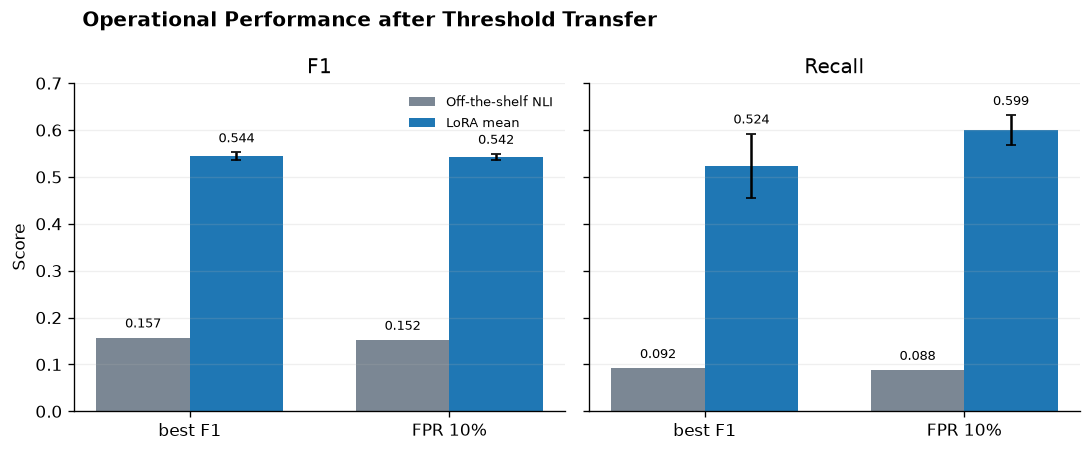

In [7]:
regimes = ["best_f1", "fpr10"]
metric_names = ["F1", "Recall"]
figure, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), sharey=True)
for axis, metric in zip(axes, metric_names):
    baseline_values = [threshold_transfer["off_the_shelf"][regime][metric] for regime in regimes]
    lora_values = [threshold_transfer["lora_mean_std"][regime][metric]["mean"] for regime in regimes]
    lora_errors = [threshold_transfer["lora_mean_std"][regime][metric]["std"] for regime in regimes]
    x = np.arange(len(regimes))
    baseline_bars = axis.bar(x - 0.18, baseline_values, 0.36, label=BASELINE_LABEL, color=COLORS[BASELINE_LABEL])
    lora_bars = axis.bar(x + 0.18, lora_values, 0.36, yerr=lora_errors, capsize=3, label="LoRA mean", color=COLORS[LORA_LABEL])
    add_bar_labels(axis, baseline_bars)
    add_bar_labels(axis, lora_bars, lora_errors)
    upper = max(max(baseline_values), max(np.asarray(lora_values) + np.asarray(lora_errors))) + 0.06
    axis.set_xticks(x, ["best F1", "FPR 10%"])
    axis.set_ylim(0, max(0.7, upper))
    axis.set_title(metric)
    axis.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Score")
axes[0].legend(frameon=False, fontsize=8)
figure.suptitle("Operational Performance after Threshold Transfer", x=0.08, ha="left", weight="bold")
figure.tight_layout()
plt.show()


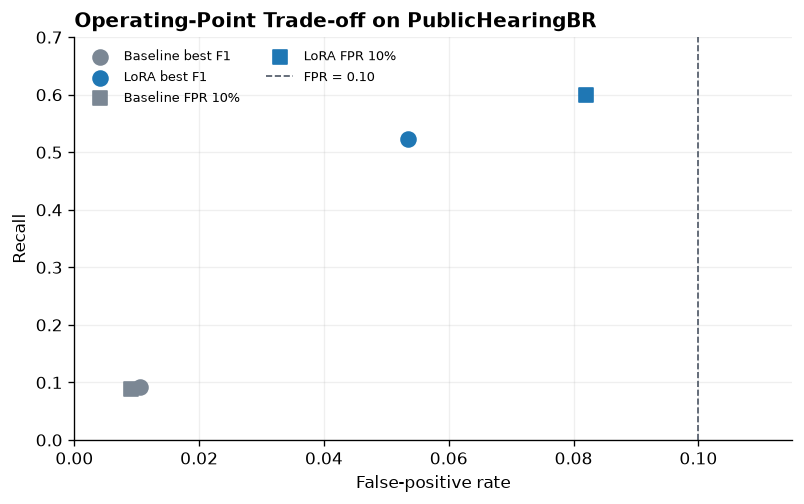

Lower FPR is not automatically better when it is achieved by detecting very few hallucinations.


In [8]:
figure, axis = plt.subplots(figsize=(6.8, 4.3))
operating_points = [
    ("Baseline best F1", "best_f1", "off_the_shelf", COLORS[BASELINE_LABEL], "o"),
    ("LoRA best F1", "best_f1", "lora_mean_std", COLORS[LORA_LABEL], "o"),
    ("Baseline FPR 10%", "fpr10", "off_the_shelf", COLORS[BASELINE_LABEL], "s"),
    ("LoRA FPR 10%", "fpr10", "lora_mean_std", COLORS[LORA_LABEL], "s"),
]
for label, regime, method, color, marker in operating_points:
    values = threshold_transfer[method][regime]
    fpr = values["FPR"] if method == "off_the_shelf" else values["FPR"]["mean"]
    recall = values["Recall"] if method == "off_the_shelf" else values["Recall"]["mean"]
    axis.scatter(fpr, recall, s=80, color=color, marker=marker, label=label, zorder=3)
axis.axvline(0.10, color="#4b5563", lw=1, ls="--", label="FPR = 0.10")
axis.set_xlim(0, 0.115)
axis.set_ylim(0, 0.7)
axis.set_xlabel("False-positive rate")
axis.set_ylabel("Recall")
axis.set_title("Operating-Point Trade-off on PublicHearingBR", loc="left", weight="bold")
axis.grid(alpha=0.2)
axis.legend(frameon=False, fontsize=8, ncols=2, loc="upper left")
figure.tight_layout()
plt.show()
print("Lower FPR is not automatically better when it is achieved by detecting very few hallucinations.")


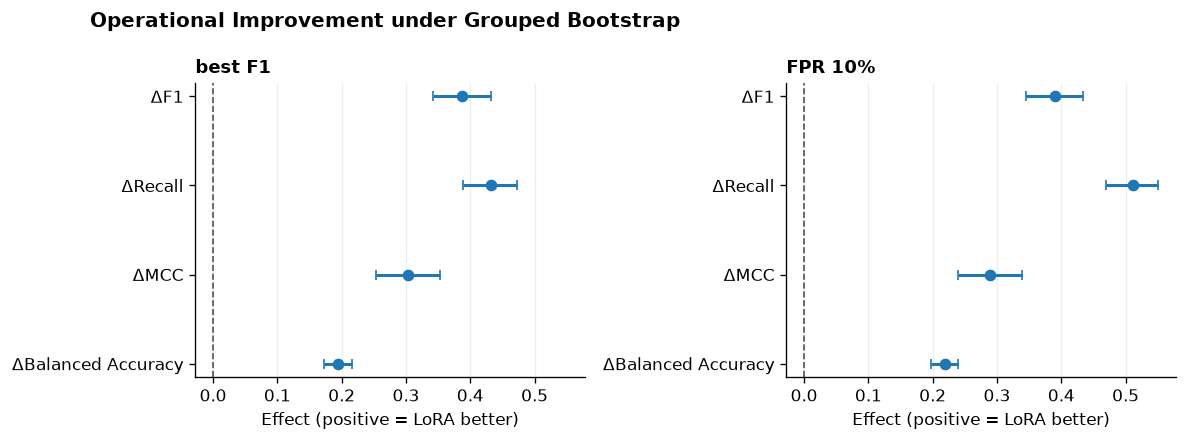

In [9]:
metrics = [("f1", "ΔF1"), ("recall", "ΔRecall"), ("mcc", "ΔMCC"), ("balanced_accuracy", "ΔBalanced Accuracy")]
figure, axes = plt.subplots(1, 2, figsize=(10, 3.7), sharex=True)
for axis, regime, color, title in zip(axes, ["best_f1", "fpr10"], [COLORS[LORA_LABEL], COLORS[LORA_LABEL]], ["best F1", "FPR 10%"]):
    entries = [thresholded_bootstrap[regime]["metrics"][key] for key, _ in metrics]
    plot_effect_ci(
        axis,
        [label for _, label in metrics],
        [entry["observed_effect"] for entry in entries],
        [entry["bootstrap"]["ci_lower"] for entry in entries],
        [entry["bootstrap"]["ci_upper"] for entry in entries],
        color,
        title,
    )
figure.suptitle("Operational Improvement under Grouped Bootstrap", x=0.08, ha="left", weight="bold")
figure.tight_layout()
plt.show()


Precision is not consistently improved. LoRA trades a higher false-positive rate for
substantially higher recall, resulting in stronger F1, MCC, and balanced accuracy.

## Conclusion

RAGTruth training strongly improves both ranking and operational transfer over the
same multilingual NLI backbone used off-the-shelf. The zero-shot model reaches
PublicHearingBR ranking performance descriptively close to the in-domain reference,
while retaining much more useful transferred operating points than the off-the-shelf
baseline. The main operational gain comes from substantially higher recall at a
higher, but still controlled, false-positive rate.
